# Project Work XAI

In [1]:
import torch

device_try = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Selected device: {device_try}")

Selected device: cuda


In [2]:
import os

print("=== TEST TMUX ===")
tmux_var = os.environ.get("TMUX")

if tmux_var:
    print("STATUS: Jupyter server is running in a TMUX session!")
    print(f"Tmux socket path: {tmux_var}")
else:
    print("STATUS: The Jupyter server is NOT inside Tmux (it runs in the global terminal).")

=== TEST TMUX ===
STATUS: Jupyter server is running in a TMUX session!
Tmux socket path: /tmp//tmux-1022/default,842946,2


In [3]:
import os
print(os.getpid())

1398786


In [4]:
import os
print("Il mio PID:", os.getpid())
print("Il PID del processo Padre (chi mi ha avviato):", os.getppid())

Il mio PID: 1398786
Il PID del processo Padre (chi mi ha avviato): 1359925


In [5]:
!nvidia-smi

Mon May 18 19:45:07 2026       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.230.02             Driver Version: 535.230.02   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA GeForce RTX 2070 ...    Off | 00000000:04:00.0 Off |                  N/A |
| 38%   28C    P8              11W / 215W |     16MiB /  8192MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [6]:
import os
import torch

print("=== 🕵️ TEST ARCHITETTURA DEFINITIVO (PYTORCH) ===")

# Verifica cosa ha ereditato dal terminale
cuda_vis = os.environ.get("CUDA_VISIBLE_DEVICES")
print(f"1. Variabile CUDA_VISIBLE_DEVICES ereditata: {cuda_vis}")

print(f"\n2. PYTORCH:")
print(f"   - Quante GPU vede all'interno del suo recinto: {torch.cuda.device_count()}")

cuda_available = torch.cuda.is_available()
if cuda_available:
    gpu_name = torch.cuda.get_device_name(0) # Usa sempre 0, perché è l'unica che vede!
    total_memory = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"   - Modello agganciato: {gpu_name}")
    print(f"   - Total VRAM memory: {total_memory:.2f} GB")
else:
    print("   - WARNING: PyTorch sta usando la CPU.")

# Test di allocazione
device = torch.device("cuda" if cuda_available else "cpu")
x = torch.randn(1000, 1000).to(device)
print(f"\nTest tensore allocato su: {x.device}")

=== 🕵️ TEST ARCHITETTURA DEFINITIVO (PYTORCH) ===
1. Variabile CUDA_VISIBLE_DEVICES ereditata: 0

2. PYTORCH:
   - Quante GPU vede all'interno del suo recinto: 1
   - Modello agganciato: NVIDIA GeForce RTX 2080 SUPER
   - Total VRAM memory: 8.36 GB

Test tensore allocato su: cuda:0


In [7]:
device = torch.device("cuda" if cuda_available else "cpu")
print(f"Device: {device}") # now it works

Device: cuda


## Environment management

In [8]:
import os
import sys

# detecting environment
def is_colab():
    try:
        import google.colab
        return True
    except ImportError:
        return False

# setting filesystem and paths
if is_colab():
    print("Running in Google Colab detected.")
    # cloning repository
    repo_url = "https://github.com/Epot12/Lab_XAI.git"
    repo_name = "Lab_XAI"

    # cloning only if it hasn't already been done in this session
    if not os.path.exists(repo_name):
        !git clone {repo_url}

    # changing the working directory to the project directory
    os.chdir(repo_name)

    # Adding the folder to the system paths
    sys.path.append(os.getcwd())
    print(f"Working directory set to: {os.getcwd()}")

else:
    from pathlib import Path
    print("Local execution detected.")
    def project_root():
        current = Path.cwd().resolve()
        for path in [current] + list(current.parents):
            if (path / ".git").exists():
                return path
        raise RuntimeError("Project root not found")

    os.chdir(project_root())
    sys.path.append(str(project_root()))
    print(f"Working directory set to: {os.getcwd()}")

Local execution detected.
Working directory set to: /home/emiliano/projects/project_1/Lab_XAI


In [9]:
# installing uv

if is_colab():
    print("Installing uv...")
    !curl -LsSf https://astral.sh/uv/install.sh | sh

    # Reload the path to show the UV track

    os.environ['PATH'] += ':/root/.cargo/bin'

    print("Environment synchronization...")
    # Synchronize Colab's system environment with local environment dependencies
    !uv pip install --system -r pyproject.toml

In [13]:
import matplotlib.pyplot as plt
import pickle
from datetime import datetime
import os
from Lab_XAI_pytorch.k_validation.K_fold import *
from Lab_XAI_pytorch.models.neural_network import *
from Lab_XAI_pytorch.utils.data_processing import *
from Lab_XAI_pytorch.utils.pipeline import pipeline

## Data extraction
In order to assess the importance of Solar Flux variable for predictions, in this evaluation such variable will be kept in the dataset and model performance will be evaluated considering data obtained in this way.

In [10]:
X, y = load_and_preprocess_data(dataset_path="Data/MARSIS_historical_dataset.csv", orbit_path="Data/orbit_to_remove", keep_flux=True)

## Creating Data Splits and Training

### Experiment 1: batch_size = 32

In [ ]:
k_fold_dict_1, save_dir_1 = pipeline(X, y, NeurNet, n_splits=10, epochs=1000, patience=10, batch_size=32, exp_name="exp_1")


--- Starting FOLD 0 ---


Early stopping at epoch 11
Train MSE: 8.685, Test MSE: 10.359

--- Starting FOLD 1 ---


Early stopping at epoch 30
Train MSE: 7.553, Test MSE: 10.232

--- Starting FOLD 2 ---


Early stopping at epoch 12
Train MSE: 8.139, Test MSE: 9.564

--- Starting FOLD 3 ---


Early stopping at epoch 11
Train MSE: 8.309, Test MSE: 14.242

--- Starting FOLD 4 ---


...

Early stopping at epoch 21
Train MSE: 6.984, Test MSE: 45.720

--- Starting FOLD 6 ---


Early stopping at epoch 12
Train MSE: 8.052, Test MSE: 40.176

--- Starting FOLD 7 ---


Early stopping at epoch 13
Train MSE: 7.602, Test MSE: 20.485

--- Starting FOLD 8 ---


Early stopping at epoch 11
Train MSE: 8.437, Test MSE: 11.089

--- Starting FOLD 9 ---


Early stopping at epoch 15
Train MSE: 7.547, Test MSE: 14.469

Execution 'exp_1' successfully completed in 13553.27s!


### Experiment 2: batch_size = 256

=== Starting Experiment Pipeline: exp_2 ===
Created isolated environment at: experiments/exp_2_20260516_155915

--- Starting FOLD 0 ---


Early stopping at epoch 11
Train MSE: 8.778, Test MSE: 8.365

--- Starting FOLD 1 ---


Early stopping at epoch 11
Train MSE: 8.473, Test MSE: 10.013

--- Starting FOLD 2 ---


Early stopping at epoch 11
Train MSE: 8.382, Test MSE: 10.455

--- Starting FOLD 3 ---


Early stopping at epoch 12
Train MSE: 7.769, Test MSE: 13.834

--- Starting FOLD 4 ---


...

Early stopping at epoch 11
Train MSE: 7.852, Test MSE: 46.011

--- Starting FOLD 6 ---


Early stopping at epoch 11
Train MSE: 8.144, Test MSE: 38.034

--- Starting FOLD 7 ---


Early stopping at epoch 11
Train MSE: 8.053, Test MSE: 20.805

--- Starting FOLD 8 ---


Early stopping at epoch 11
Train MSE: 9.472, Test MSE: 18.197

--- Starting FOLD 9 ---


Early stopping at epoch 15
Train MSE: 7.237, Test MSE: 15.221

Execution 'exp_2' successfully completed in 1914.31s!
Generating Learning Curves...


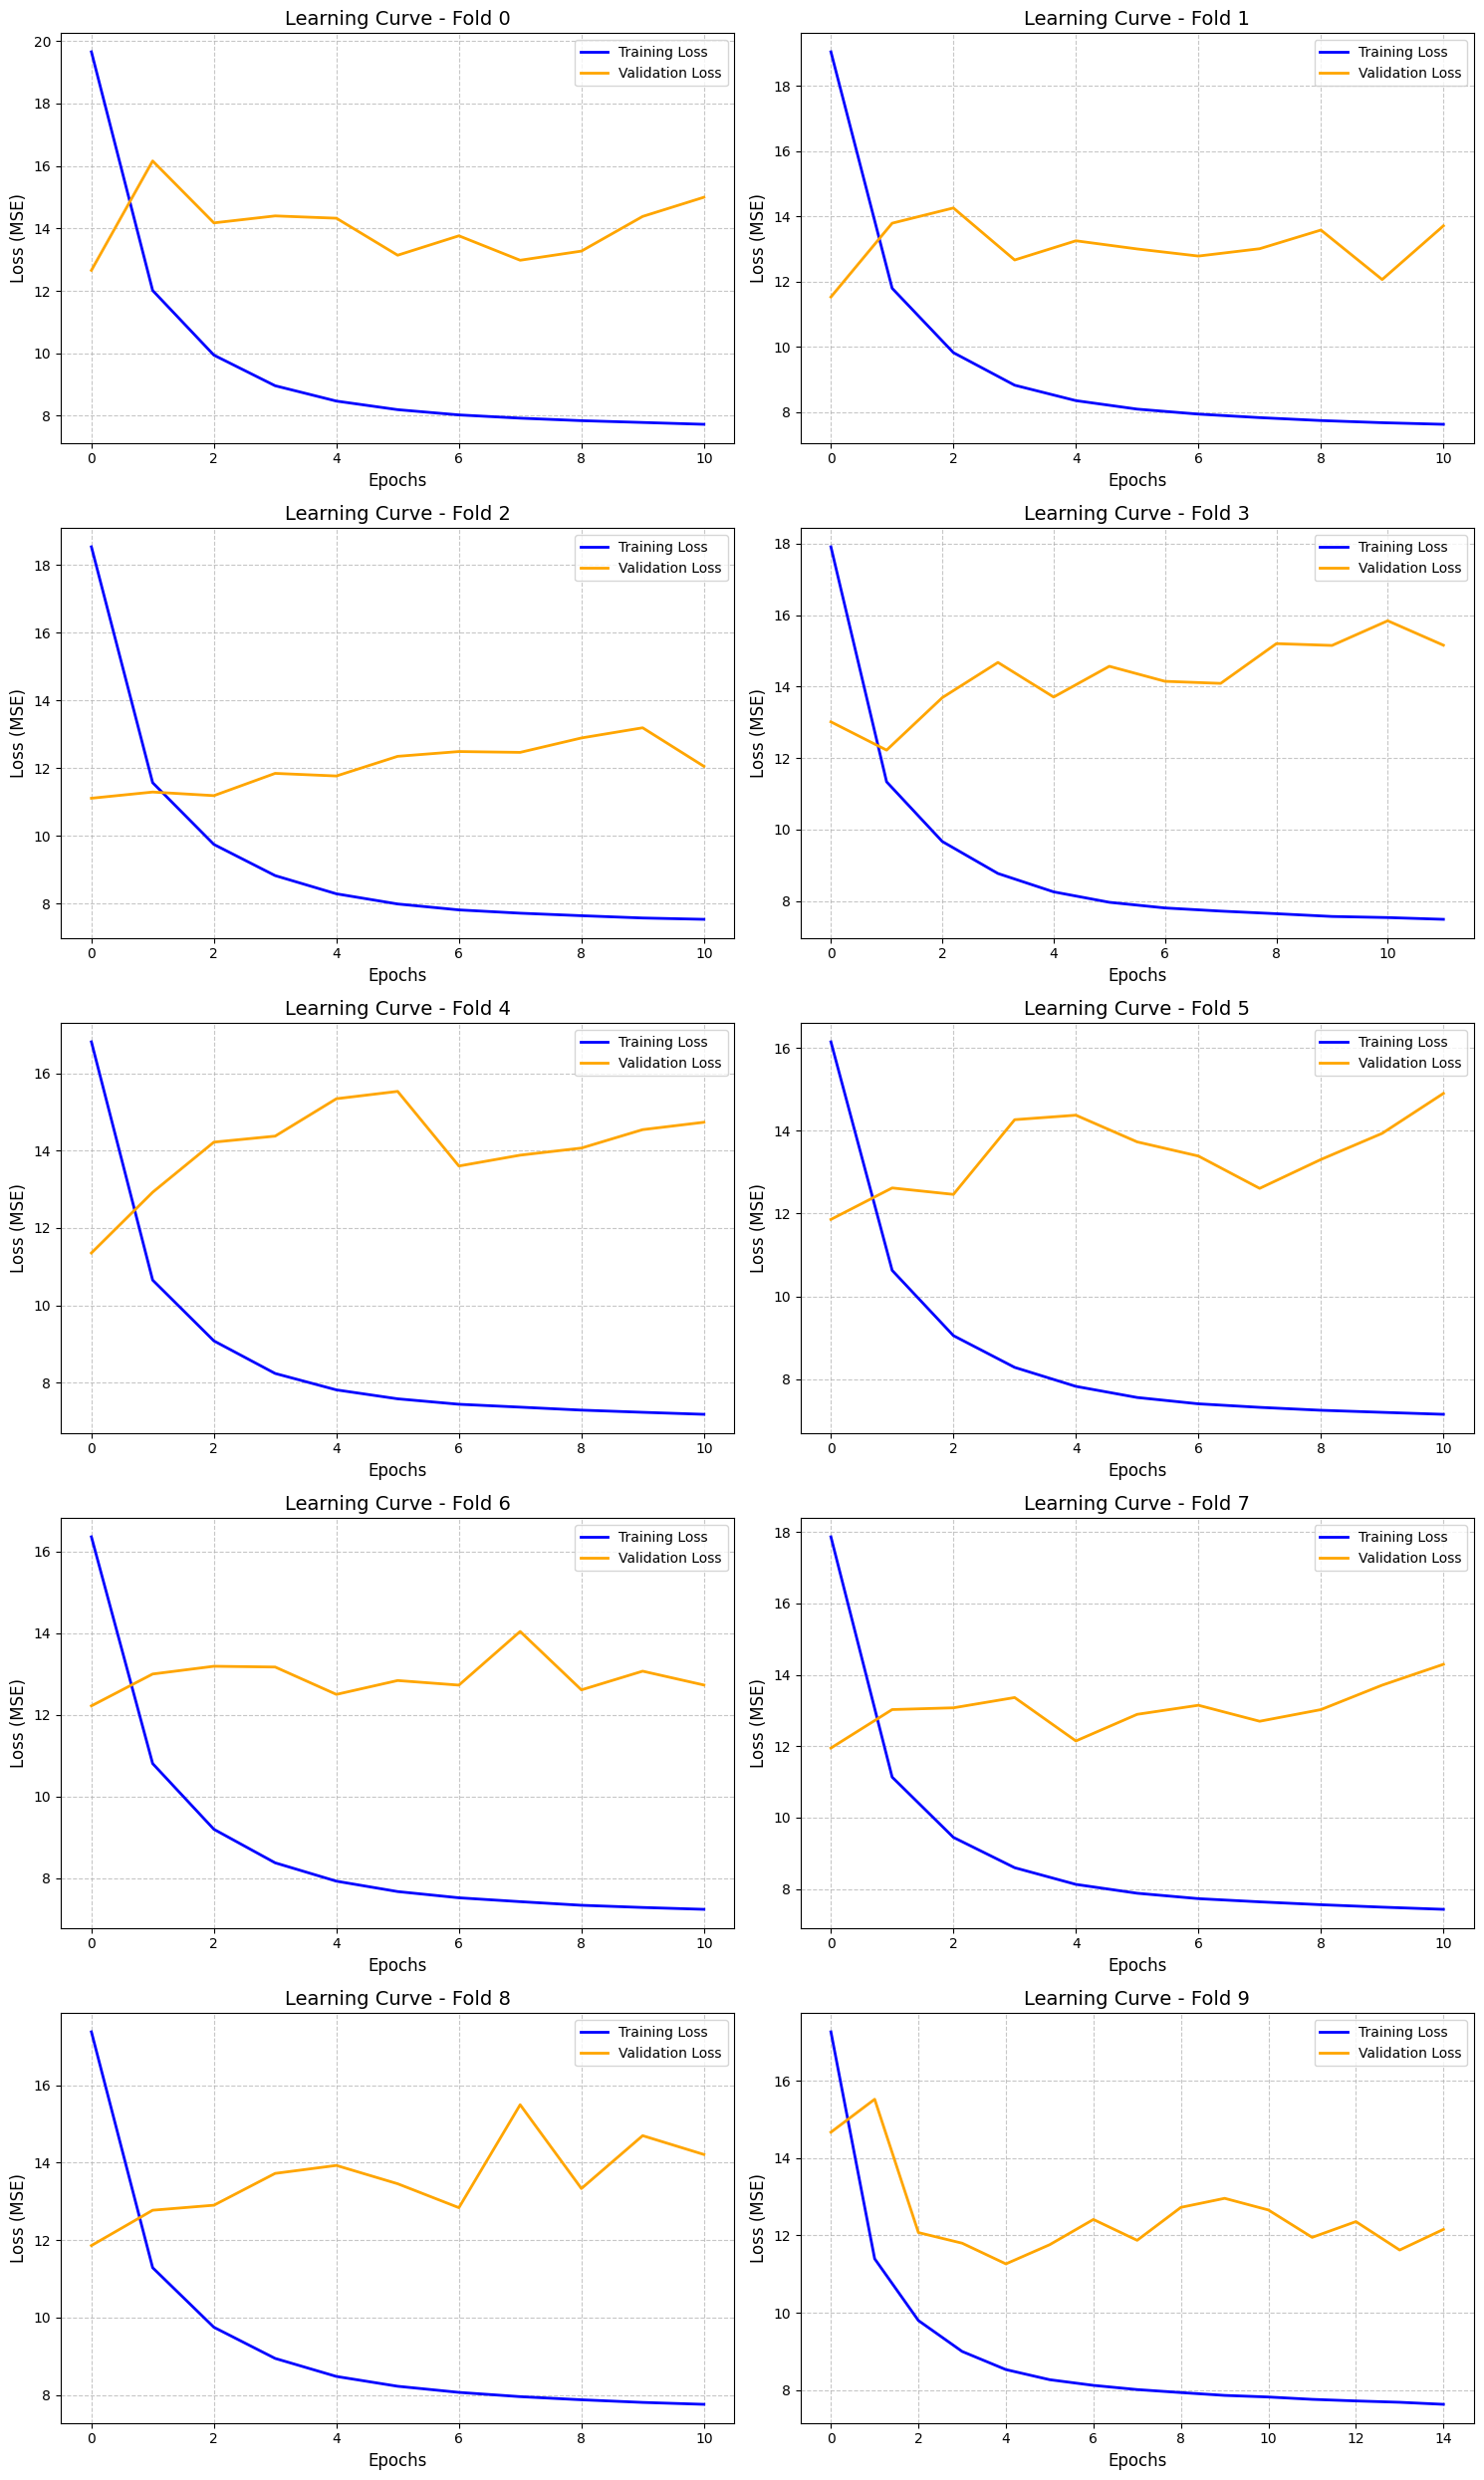

Experiment completely saved in: /home/emiliano/projects/project_1/Lab_XAI/experiments/exp_2_20260516_155915


In [11]:
k_fold_dict_2, save_dir_2 = pipeline(X, y, NeurNet, n_splits=10, epochs=1000, patience=10, batch_size=256, exp_name="exp_2")

In [12]:
print(k_fold_dict_2)

{'MAE': 3.370018347040911, 'MAPE': 0.25563652946529525, 'MSE': 21.30989163630756, 'predictions': array([12.59172058, 12.59132671, 12.59096813, ..., 11.67141724,
       11.66817188, 11.66492653], shape=(1905841,)), 'execution_time': 1914.3073630332947, 'histories': [{'train_loss': [np.float64(19.6568941647013), np.float64(12.013114592464108), np.float64(9.942472551181687), np.float64(8.96185637540316), np.float64(8.470467870734735), np.float64(8.195428006231163), np.float64(8.027416511033428), np.float64(7.923415067322), np.float64(7.843182303185606), np.float64(7.7853362569364615), np.float64(7.726424845311401)], 'val_loss': [12.658727645874023, 16.161497116088867, 14.178004264831543, 14.40145492553711, 14.3273344039917, 13.14233684539795, 13.764396667480469, 12.981348991394043, 13.274319648742676, 14.384540557861328, 14.998696327209473]}, {'train_loss': [np.float64(19.05168944048735), np.float64(11.796182740922593), np.float64(9.821664746691983), np.float64(8.822877163081358), np.floa

### Experiment 3: batch_size = 32 no flux

In [14]:
X_3, y_3 = load_and_preprocess_data(dataset_path="Data/MARSIS_historical_dataset.csv", orbit_path="Data/orbit_to_remove", keep_flux=False)

=== Starting Experiment Pipeline: exp_3 ===
Created isolated environment at: experiments/exp_3_20260518_194659

--- Starting FOLD 0 ---


Early stopping at epoch 13
Train MSE: 8.802, Test MSE: 16.489

--- Starting FOLD 1 ---


Early stopping at epoch 11
Train MSE: 8.687, Test MSE: 10.205

--- Starting FOLD 2 ---


Early stopping at epoch 11
Train MSE: 8.466, Test MSE: 10.256

--- Starting FOLD 3 ---


Early stopping at epoch 11
Train MSE: 8.974, Test MSE: 15.643

--- Starting FOLD 4 ---


...

Early stopping at epoch 11
Train MSE: 8.526, Test MSE: 44.404

--- Starting FOLD 6 ---


Early stopping at epoch 11
Train MSE: 8.605, Test MSE: 42.213

--- Starting FOLD 7 ---


Early stopping at epoch 11
Train MSE: 8.703, Test MSE: 20.426

--- Starting FOLD 8 ---


Early stopping at epoch 11
Train MSE: 8.644, Test MSE: 28.011

--- Starting FOLD 9 ---


Early stopping at epoch 14
Train MSE: 8.786, Test MSE: 16.746

Execution 'exp_3' successfully completed in 10688.10s!
Generating Learning Curves...


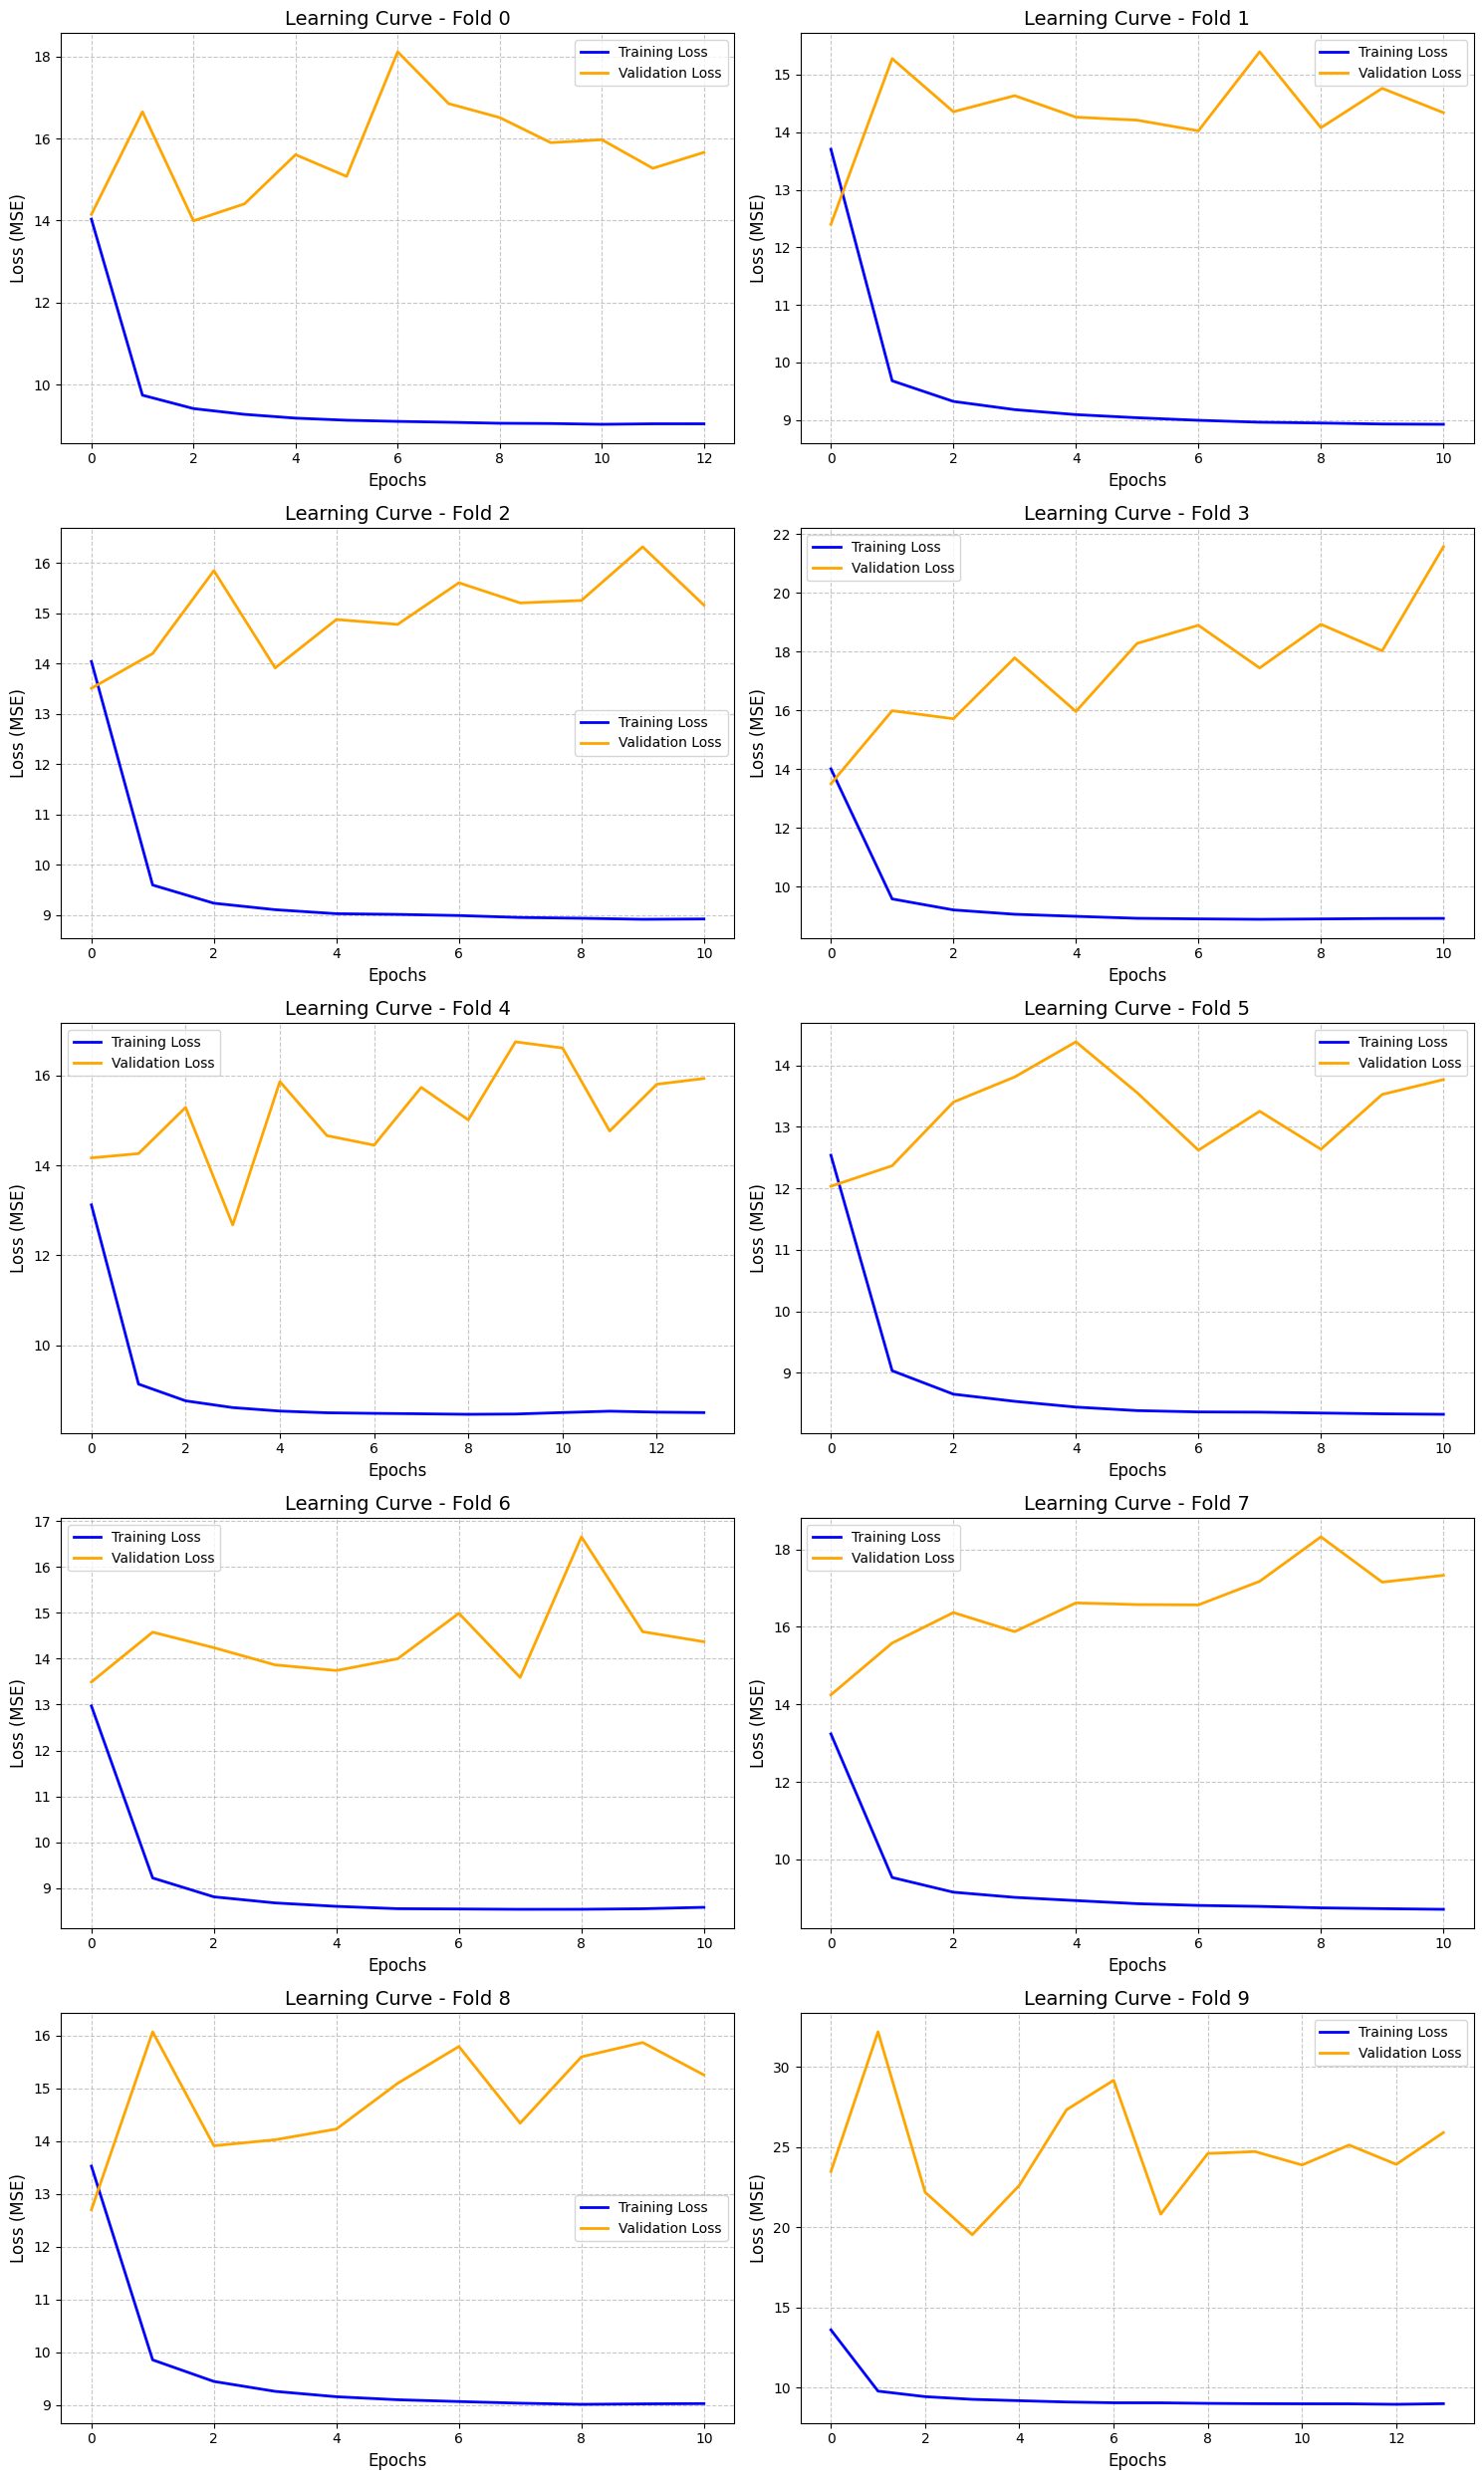

Experiment completely saved in: /home/emiliano/projects/project_1/Lab_XAI/experiments/exp_3_20260518_194659


In [15]:
k_fold_dict_3, save_dir_3 = pipeline(X_3, y_3, NeurNet, n_splits=10, epochs=1000, patience=10, batch_size=32, exp_name="exp_3")

## SHAP

### SHAP on experiment 2

In [ ]:
feature_names_2 = extract_feature_names(dataset_path="Data/MARSIS_historical_dataset.csv", keep_flux=True)
input_d_2 = X_train_fold0.shape[1]
shap_values_2, X_test_scaled_2 = explain_with_shap(model, weights_path, scaler_path, X_background_raw, X_test_raw, feature_names, bg_limit=500, test_limit=None)